In [1]:
import pandas as pd
from glob import glob
from braceexpand import braceexpand
import numpy as np
import matplotlib.pyplot as plt
import pickle
import xarray as xr
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import open_files, calculate_ranking

In [2]:
sim = 'ERA5'
quantile = 0.99

if sim == 'UBB' or sim == 'ERA5':
    endyear = 2023
else:
    endyear = 2014

In [3]:
df, _ = open_files(sim)
df

,storm,i,j,point,date,lat,lon,pressure
0,1,17,104,154,1979-01-01 16:00:00,37.75,-145.25,992.653
1,1,18,105,153,1979-01-01 17:00:00,38.00,-145.00,993.176
2,1,19,105,152,1979-01-01 18:00:00,38.25,-145.00,993.394
3,1,20,106,152,1979-01-01 19:00:00,38.25,-144.75,993.649
4,1,21,106,150,1979-01-01 20:00:00,38.75,-144.75,993.722
...,...,...,...,...,...,...,...,...
854408,14019,31,480,88,2023-08-31 19:00:00,54.25,-51.25,981.161
854409,14019,32,481,87,2023-08-31 20:00:00,54.50,-51.00,980.421
854410,14019,33,483,86,2023-08-31 21:00:00,54.75,-50.50,979.833
854411,14019,34,484,85,2023-08-31 22:00:00,55.00,-50.25,977.626


In [4]:
(
    sorted_EETC_cum_rank,
    sorted_EETC_cum_avg_rank,
    sorted_EETC_cum_SSI_rank,
    sorted_EETC_cum_avg_SSI_rank,
    combined_scores,
    combined_avg_scores,
    combined_SSI_scores,
    combined_SSI_avg_scores,
    EETC_dict,
    EETC_dict_norm
) = calculate_ranking(sim=sim, quantile=quantile, ref=False, method='product')

In [5]:
for storm in EETC_dict:
    if EETC_dict[storm]['cum_precip'].sel(quantile=quantile).values or EETC_dict[storm]['cum_avg_precip'].sel(quantile=quantile).values or EETC_dict[storm]['cum_wind'].sel(quantile=quantile).values or EETC_dict[storm]['cum_avg_wind'].sel(quantile=quantile).values or EETC_dict[storm]['SSI'].sel(quantile=quantile).values != 0:
        storm_group = df.groupby('storm').get_group(storm)
        min_pressure_row = storm_group.loc[storm_group['pressure'].idxmin()]
        EETC_dict[storm]['min_pressure_date'] = min_pressure_row['date']

In [6]:
# --- 1) Ranking pour chaque métrique ---
def top_keys(ETC_dict, metric, quantile=0.99):
    values = {}
    for k, v in EETC_dict.items():
        da = v[metric]
        val = da.sel(quantile=quantile).item()
        values[k] = val
    # Trier par valeur décroissante
    return sorted(values, key=values.get, reverse=True)

top_cum_precip     = top_keys(EETC_dict, "cum_precip", 0.99)
top_cum_avg_precip = top_keys(EETC_dict, "cum_avg_precip", 0.99)
top_cum_wind       = top_keys(EETC_dict, "cum_wind", 0.99)
top_cum_avg_wind   = top_keys(EETC_dict, "cum_avg_wind", 0.99)

# --- 2) Compter par saisons ---
def count_by_season(keys, EETC_dict):
    counts = {"DJF": 0, "MAM": 0, "JJA": 0, "SON": 0}
    for k in keys:
        date = EETC_dict[k]["min_pressure_date"]
        m = date.month
        if   m in [12, 1, 2]: counts["DJF"] += 1
        elif m in [3, 4, 5]:  counts["MAM"] += 1
        elif m in [6, 7, 8]:  counts["JJA"] += 1
        elif m in [9, 10, 11]:counts["SON"] += 1
    return counts

season_cum_precip     = count_by_season(top_cum_precip[:15], EETC_dict)
season_cum_avg_precip = count_by_season(top_cum_avg_precip[:15], EETC_dict)
season_cum_wind       = count_by_season(top_cum_wind[:15], EETC_dict)
season_cum_avg_wind   = count_by_season(top_cum_avg_wind[:15], EETC_dict)

# --- 3) Faire pareil pour combined_scores et combined_avg_scores ---
def top_keys_combined(combined_dict, EETC_dict, quantile=0.99, n=15):
    values = {}
    # Convertit le quantile float en clé string comme dans ETC_dict["compound_8hrs_quantile"]
    q_key = str(quantile * 100).rstrip("0").rstrip(".")
    for k, da in combined_dict.items():
        if "compound_8hrs_quantile" in EETC_dict[k]:
            cond = EETC_dict[k]["compound_8hrs_quantile"]
            if q_key in cond and cond[q_key]:
                val = da.item()
                values[k] = val
    return sorted(values, key=values.get, reverse=True)[:n]

top_combined_scores      = top_keys_combined(combined_scores, EETC_dict, 0.99)
top_combined_avg_scores  = top_keys_combined(combined_avg_scores, EETC_dict, 0.99)

season_combined_scores     = count_by_season(top_combined_scores, EETC_dict)
season_combined_avg_scores = count_by_season(top_combined_avg_scores, EETC_dict)

## Juste pour les PowerPoint

Cette partie sert juste à plot ce que je veux montrer dans les ppt

In [7]:
plot_params = [
    {
        "var_precip": "cum_precip",
        "var_wind": "cum_wind",
        "rank_var": sorted_EETC_cum_rank,
        "ylabel": rf'$ETC_{{PR,\,cum}}^{{{sim}}}|_{{QC}}$ [mm]',
        "xlabel": rf'$ETC_{{WS,\,cum}}^{{{sim}}}|_{{QC}}$ [km.h$^{{-1}}$]',
        "colors": combined_scores,
        "ax_index": 0
    },
    {
        "var_precip": "cum_avg_precip",
        "var_wind": "cum_avg_wind",
        "rank_var": sorted_EETC_cum_avg_rank,
        "ylabel": rf'$\overline{{ETC_{{PR}}^{{{sim}}}|_{{QC}}}}$ [mm.h$^{{-1}}$]',
        "xlabel": rf'$\overline{{ETC_{{WS}}^{{{sim}}}|_{{QC}}}}$ [km.h$^{{-1}}$]',
        "colors": combined_avg_scores,
        "ax_index": 1
    },
]

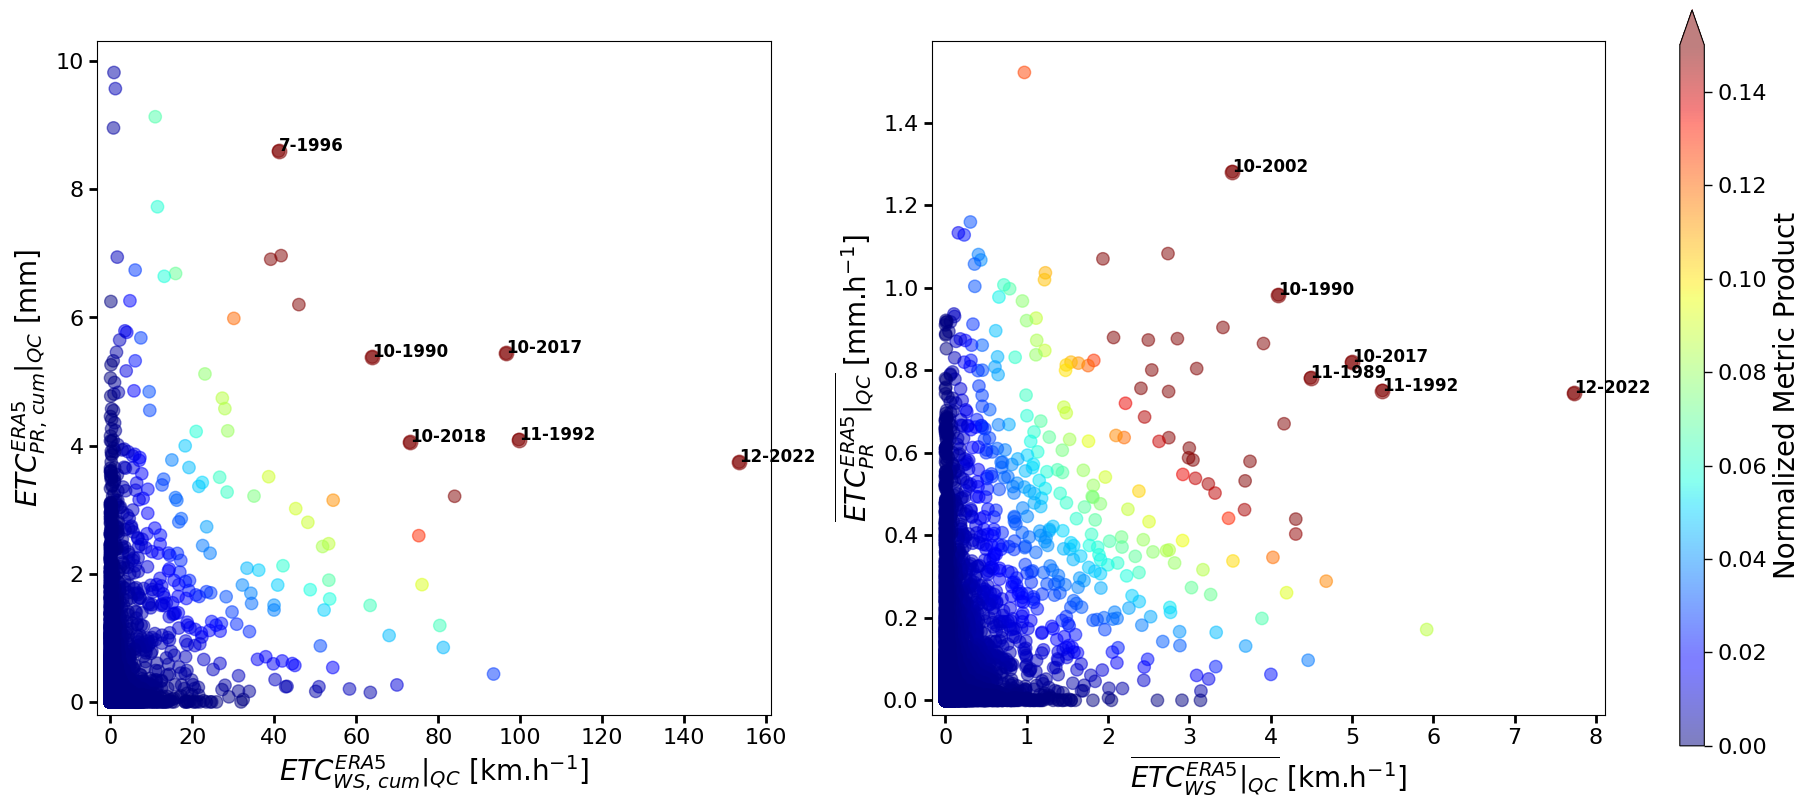

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for params in plot_params:
    
    # Récupération des valeurs x et y
    x = [EETC_dict[k][params["var_wind"]].sel(quantile=quantile).values for k in params["rank_var"]]
    y = [EETC_dict[k][params["var_precip"]].sel(quantile=quantile).values for k in params["rank_var"]]

    colors = [params["colors"][k] for k in params["rank_var"]]
    ax = axes[params["ax_index"]]
    # vmax = max(combined_scores[sorted_EETC_cum_rank[0]], combined_avg_scores[sorted_EETC_cum_avg_rank[0]], combined_SSI_scores[sorted_EETC_cum_SSI_rank[0]], combined_SSI_avg_scores[sorted_EETC_cum_avg_SSI_rank[0]])
    vmax = 0.15
    
    # Scatter plot des points avec les couleurs définies
    sc = ax.scatter(x, y, c=colors, s=80, alpha=0.5, cmap='jet', vmin=0, vmax=vmax)

    for i in range(6):
        ax.scatter(x[i], y[i], c=colors[i], s=110, alpha=0.5, cmap='jet', vmin=sc.norm.vmin, vmax=sc.norm.vmax)
        ax.annotate(f"{EETC_dict[params['rank_var'][i]]['min_pressure_date'].month}-{EETC_dict[params['rank_var'][i]]['min_pressure_date'].year}", (x[i], y[i]), fontsize=12, fontweight='bold')
    
    # id_storm = 12824
    # if id_storm in params["rank_var"]:
    #     idx = params["rank_var"].index(id_storm)
    #     ax.scatter(x[idx], y[idx], c=[colors[idx]], cmap='jet_r', vmin=0, vmax=vmax, edgecolors='black', s=100, marker='*', label='Halloween Storm')
    
    if params["ax_index"] == 0:
        ax.set_xlim(left=-3.3)
        ax.set_ylim(bottom=-.2)
    else:
        ax.set_xlim(left=-0.17)
        ax.set_ylim(bottom=-.035)
    ax.set_box_aspect(1)
    ax.set_xlabel(params["xlabel"], fontsize=20)
    ax.set_ylabel(params["ylabel"], fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=4)

# Colorbar pour les points du scatter
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', shrink=1, pad=0.02, aspect=30, extend='max')
cbar.ax.tick_params(labelsize=16, length=6, width=1)
cbar.set_label('Normalized Metric Product', fontsize=20)

# fig.suptitle(f"{sim} strongest ETCs over Québec from 1979 to {endyear} - ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)
# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/scatter_plot_ERA5.png', dpi=70, bbox_inches='tight', transparent=True)

In [9]:
len(y)

4860

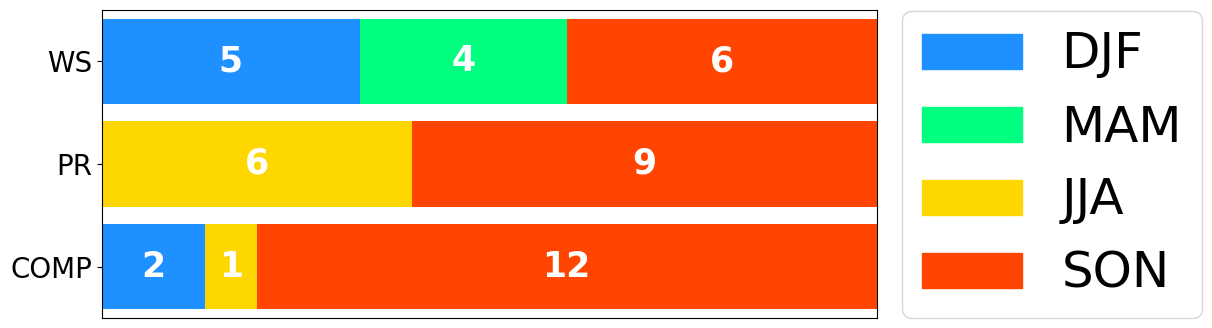

In [10]:
season_colors = {"DJF": "dodgerblue", "MAM": "springgreen", "JJA": "gold", "SON": "orangered"}

# Exemple de données
season_sets = [
    season_cum_wind,          # WS
    season_cum_precip,        # PR
    season_combined_scores     # COMP
]
labels = ["WS", "PR", "COMP"]

fig, ax = plt.subplots(figsize=(10, 4))

y_positions = [0.6, 0.3, 0]  # WS en haut, PR au milieu, COMP en bas
bar_height = 0.25

# Tracer les barres empilées
for y, season_count, label in zip(y_positions, season_sets, labels):
    left = 0
    for season in ["DJF", "MAM", "JJA", "SON"]:
        count = season_count[season]
        ax.barh(y, count, left=left, color=season_colors[season], height=bar_height)
        if count > 0:
            ax.text(left + count/2, y, str(count), va='center', ha='center', color='white', fontsize=25, fontweight='bold')
        left += count

# Axe x invisible
ax.xaxis.set_visible(False)

# Axe y avec labels
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=20)

ax.set_xlim(0, 15)
ax.set_ylim(y_positions[2]-((y_positions[1]-y_positions[2])/2), y_positions[0]+((y_positions[1]-y_positions[2])/2))

# Légende à droite, occupant la même hauteur que l'axe y
handles = [plt.Rectangle((0,0),1,1,color=season_colors[s]) for s in season_colors]
ax.legend(handles, season_colors.keys(), loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=36, title_fontsize=12)

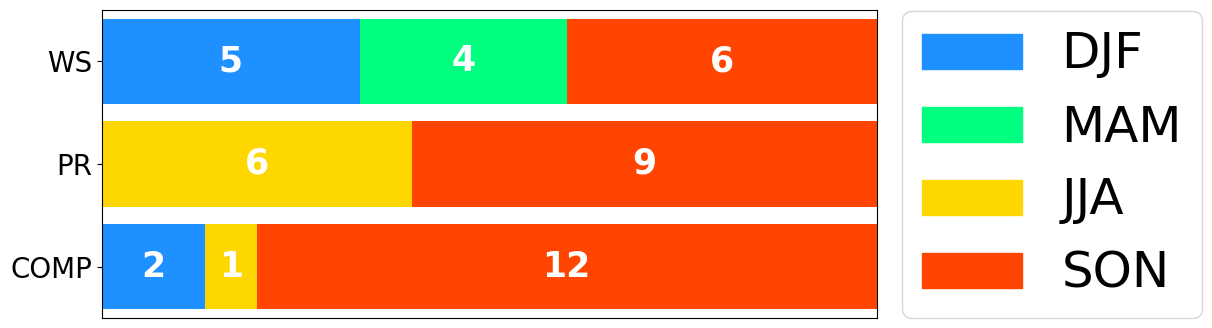

In [11]:
season_colors = {"DJF": "dodgerblue", "MAM": "springgreen", "JJA": "gold", "SON": "orangered"}

# Exemple de données
season_sets = [
    season_cum_avg_wind,          # WS
    season_cum_avg_precip,        # PR
    season_combined_avg_scores     # COMP
]
labels = ["WS", "PR", "COMP"]

fig, ax = plt.subplots(figsize=(10, 4))

y_positions = [0.6, 0.3, 0]  # WS en haut, PR au milieu, COMP en bas
bar_height = 0.25

# Tracer les barres empilées
for y, season_count, label in zip(y_positions, season_sets, labels):
    left = 0
    for season in ["DJF", "MAM", "JJA", "SON"]:
        count = season_count[season]
        ax.barh(y, count, left=left, color=season_colors[season], height=bar_height)
        if count > 0:
            ax.text(left + count/2, y, str(count), va='center', ha='center', color='white', fontsize=25, fontweight='bold')
        left += count

# Axe x invisible
ax.xaxis.set_visible(False)

# Axe y avec labels
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=20)

ax.set_xlim(0, 15)
ax.set_ylim(y_positions[2]-((y_positions[1]-y_positions[2])/2), y_positions[0]+((y_positions[1]-y_positions[2])/2))

# Légende à droite, occupant la même hauteur que l'axe y
handles = [plt.Rectangle((0,0),1,1,color=season_colors[s]) for s in season_colors]
ax.legend(handles, season_colors.keys(), loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=36, title_fontsize=12)

In [12]:
def make_top_metric_table(top_ids, EETC_dict, df, sim, quantile=0.99):
    rows = []
    
    for storm_id in top_ids[:20]:
        # Récupérer le storm_group dans df
        storm_group = df.groupby('storm').get_group(storm_id)
        min_pressure_row = storm_group.loc[storm_group['pressure'].idxmin()]
        
        date_str = EETC_dict[storm_id]['min_pressure_date'].strftime("%Y-%m")
        pmin = min_pressure_row['pressure']
        
        # Valeurs des métriques
        cum_precip_val = EETC_dict[storm_id]["cum_precip"].sel(quantile=quantile).values.item()
        cum_avg_precip_val = EETC_dict[storm_id]["cum_avg_precip"].sel(quantile=quantile).values.item()
        cum_wind_val = EETC_dict[storm_id]["cum_wind"].sel(quantile=quantile).values.item()
        cum_avg_wind_val = EETC_dict[storm_id]["cum_avg_wind"].sel(quantile=quantile).values.item()
        
        # Rang pour chaque métrique
        rank_cum_precip_val     = top_cum_precip.index(storm_id) + 1
        rank_cum_avg_precip_val = top_cum_avg_precip.index(storm_id) + 1
        rank_cum_wind_val       = top_cum_wind.index(storm_id) + 1
        rank_cum_avg_wind_val   = top_cum_avg_wind.index(storm_id) + 1
        
        row = {
            "ETC/nID no.": storm_id,
            "Date (yyyy-mm)": date_str,
            "Peak intensity (pmin (hPa))": pmin,
            'cum_precip': cum_precip_val,
            "rank_cum_precip": rank_cum_precip_val,
            'cum_wind': cum_wind_val,
            "rank_cum_wind": rank_cum_wind_val,
            'cum_avg_precip': cum_avg_precip_val,
            "rank_cum_avg_precip": rank_cum_avg_precip_val,           
            'cum_avg_wind': cum_avg_wind_val,
            "rank_cum_avg_wind": rank_cum_avg_wind_val
        }
        rows.append(row)
        
    return pd.DataFrame(rows)

# Exemple pour top_cum_precip
df_top_cum_precip = make_top_metric_table(top_cum_precip, EETC_dict, df, sim)

# Pareil pour les autres métriques
df_top_cum_avg_precip = make_top_metric_table(top_cum_avg_precip, EETC_dict, df, sim)
df_top_cum_wind = make_top_metric_table(top_cum_wind, EETC_dict, df, sim)
df_top_cum_avg_wind = make_top_metric_table(top_cum_avg_wind, EETC_dict, df, sim)

# Exporter chaque tableau
output_dir = f"/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/TABLE"
df_top_cum_precip.to_csv(f"{output_dir}/top_cum_precip.csv", index=False)
df_top_cum_avg_precip.to_csv(f"{output_dir}/top_cum_avg_precip.csv", index=False)
df_top_cum_wind.to_csv(f"{output_dir}/top_cum_wind.csv", index=False)
df_top_cum_avg_wind.to_csv(f"{output_dir}/top_cum_avg_wind.csv", index=False)

# Afficher
df_top_cum_precip

,ETC/nID no.,Date (yyyy-mm),Peak intensity/n(pmin (hPa)),cum_precip,rank_cum_precip,cum_wind,rank_cum_wind,cum_avg_precip,rank_cum_avg_precip,cum_avg_wind,rank_cum_avg_wind
0,3622,1990-09,989.021,9.822679,1,0.856045,1219,1.132660,4,0.158567,1348
1,8343,2005-08,982.066,9.571028,2,1.198308,1061,1.158966,3,0.306502,920
2,10263,2011-08,981.115,9.132567,3,10.926172,228,0.837189,46,1.112712,252
3,4273,1992-08,995.493,8.957973,4,0.744565,1285,1.127615,5,0.230238,1097
4,5508,1996-07,981.533,8.596435,5,41.054176,38,0.755965,75,2.404196,69
5,3294,1989-09,981.690,7.727513,6,11.474827,214,1.069702,8,1.936536,100
6,7445,2002-10,965.270,6.965238,7,41.640461,37,1.280734,2,3.527773,22
7,12159,2017-08,989.783,6.941988,8,1.660408,887,1.066957,9,0.434868,703
8,2369,1986-09,986.723,6.908642,9,39.105175,44,0.810963,57,1.753823,123
9,10609,2012-09,975.346,6.739779,10,6.030215,389,1.035861,11,1.229156,217


## On reprend les plots normaux

Hors ppt. Nécessite quelques ajustements

In [42]:
plot_params = [
    {
        "var_precip": "cum_precip",
        "var_wind": "cum_wind",
        "rank_var": sorted_EETC_cum_rank,
        "ylabel": '$ETC_{PR, cum}$',
        "xlabel": '$ETC_{WS, cum}$',
        "colors": combined_scores,
        "ax_index": (0, 0)
    },
    {
        "var_precip": "cum_avg_precip",
        "var_wind": "cum_avg_wind",
        "rank_var": sorted_EETC_cum_avg_rank,
        "ylabel": '$\overline{{ETC}_{PR}}$',
        "xlabel": '$\overline{{ETC}_{WS}}$',
        "colors": combined_avg_scores,
        "ax_index": (0, 1)
    },
    {
        "var_precip": "cum_precip",
        "var_wind": "SSI",
        "rank_var": sorted_EETC_cum_SSI_rank,
        "ylabel": '$ETC_{PR, cum}$',
        "xlabel": '$SSI$',
        "colors": combined_SSI_scores,
        "ax_index": (1, 0)
    },
    {
        "var_precip": "cum_avg_precip",
        "var_wind": "SSI",
        "rank_var": sorted_EETC_cum_avg_SSI_rank,
        "ylabel": '$\overline{{ETC}_{PR}}$',
        "xlabel": '$SSI$',
        "colors": combined_SSI_avg_scores,
        "ax_index": (1, 1)
    }
]

Text(0.5, 0.98, 'UBF strongest ETCs over Québec from 1979 to 2014 - $99.9^{th}$ percentile')

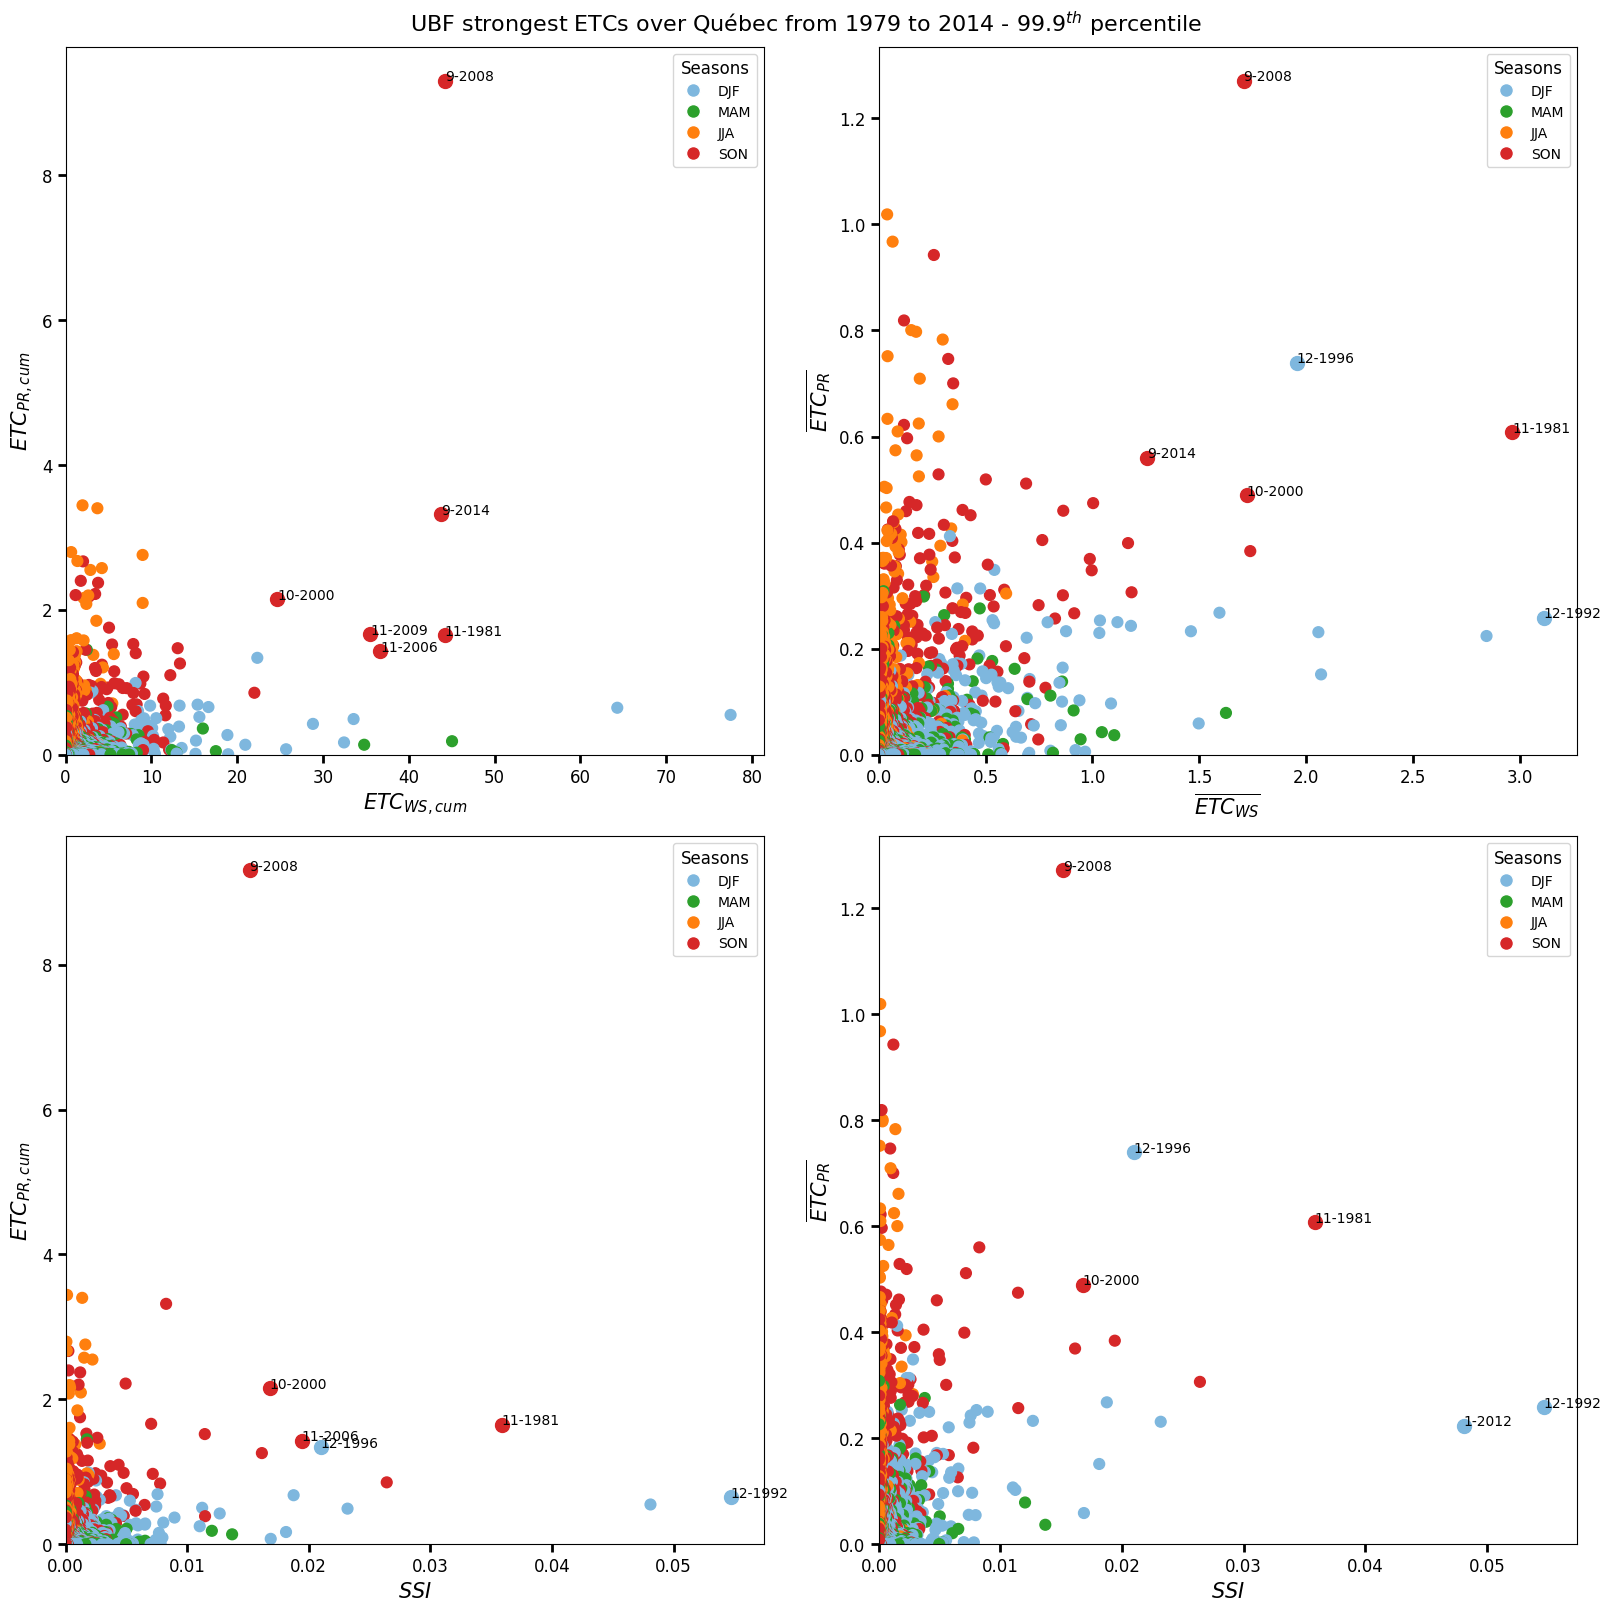

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16), constrained_layout=True)

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:      
        
    # Récupération des valeurs x et y
    x = [EETC_dict[k][params["var_wind"]].sel(quantile=quantile).values for k in params["rank_var"]]
    y = [EETC_dict[k][params["var_precip"]].sel(quantile=quantile).values for k in params["rank_var"]]
    
    colors = []
    for k in params["rank_var"]:
        month = EETC_dict[k]['min_pressure_date'].month
        for season, months in seasons.items():
            if month in months:
                colors.append(season_color[season])
                break
    
    ax = axes[params["ax_index"]]
    
    sc = ax.scatter(x, y, c=colors, s=60)

    for i in range(6):
        ax.scatter(x[i], y[i], c=colors[i], s=100)
        ax.annotate(f"{EETC_dict[params['rank_var'][i]]['min_pressure_date'].month}-{EETC_dict[params['rank_var'][i]]['min_pressure_date'].year}", (x[i], y[i]), fontsize=10)
    
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=season) 
               for season, color in season_color.items()]
    ax.legend(handles=handles, title="Seasons", fontsize=10, title_fontsize=12, loc='upper right')
    
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(params["xlabel"], fontsize=15)
    ax.set_ylabel(params["ylabel"], fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)

fig.suptitle(f"{sim} strongest ETCs over Québec from 1979 to {endyear} - ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'ERA5 strongest ETCs over Québec from 1979 to 2023 - $99.9^{th}$ percentile')

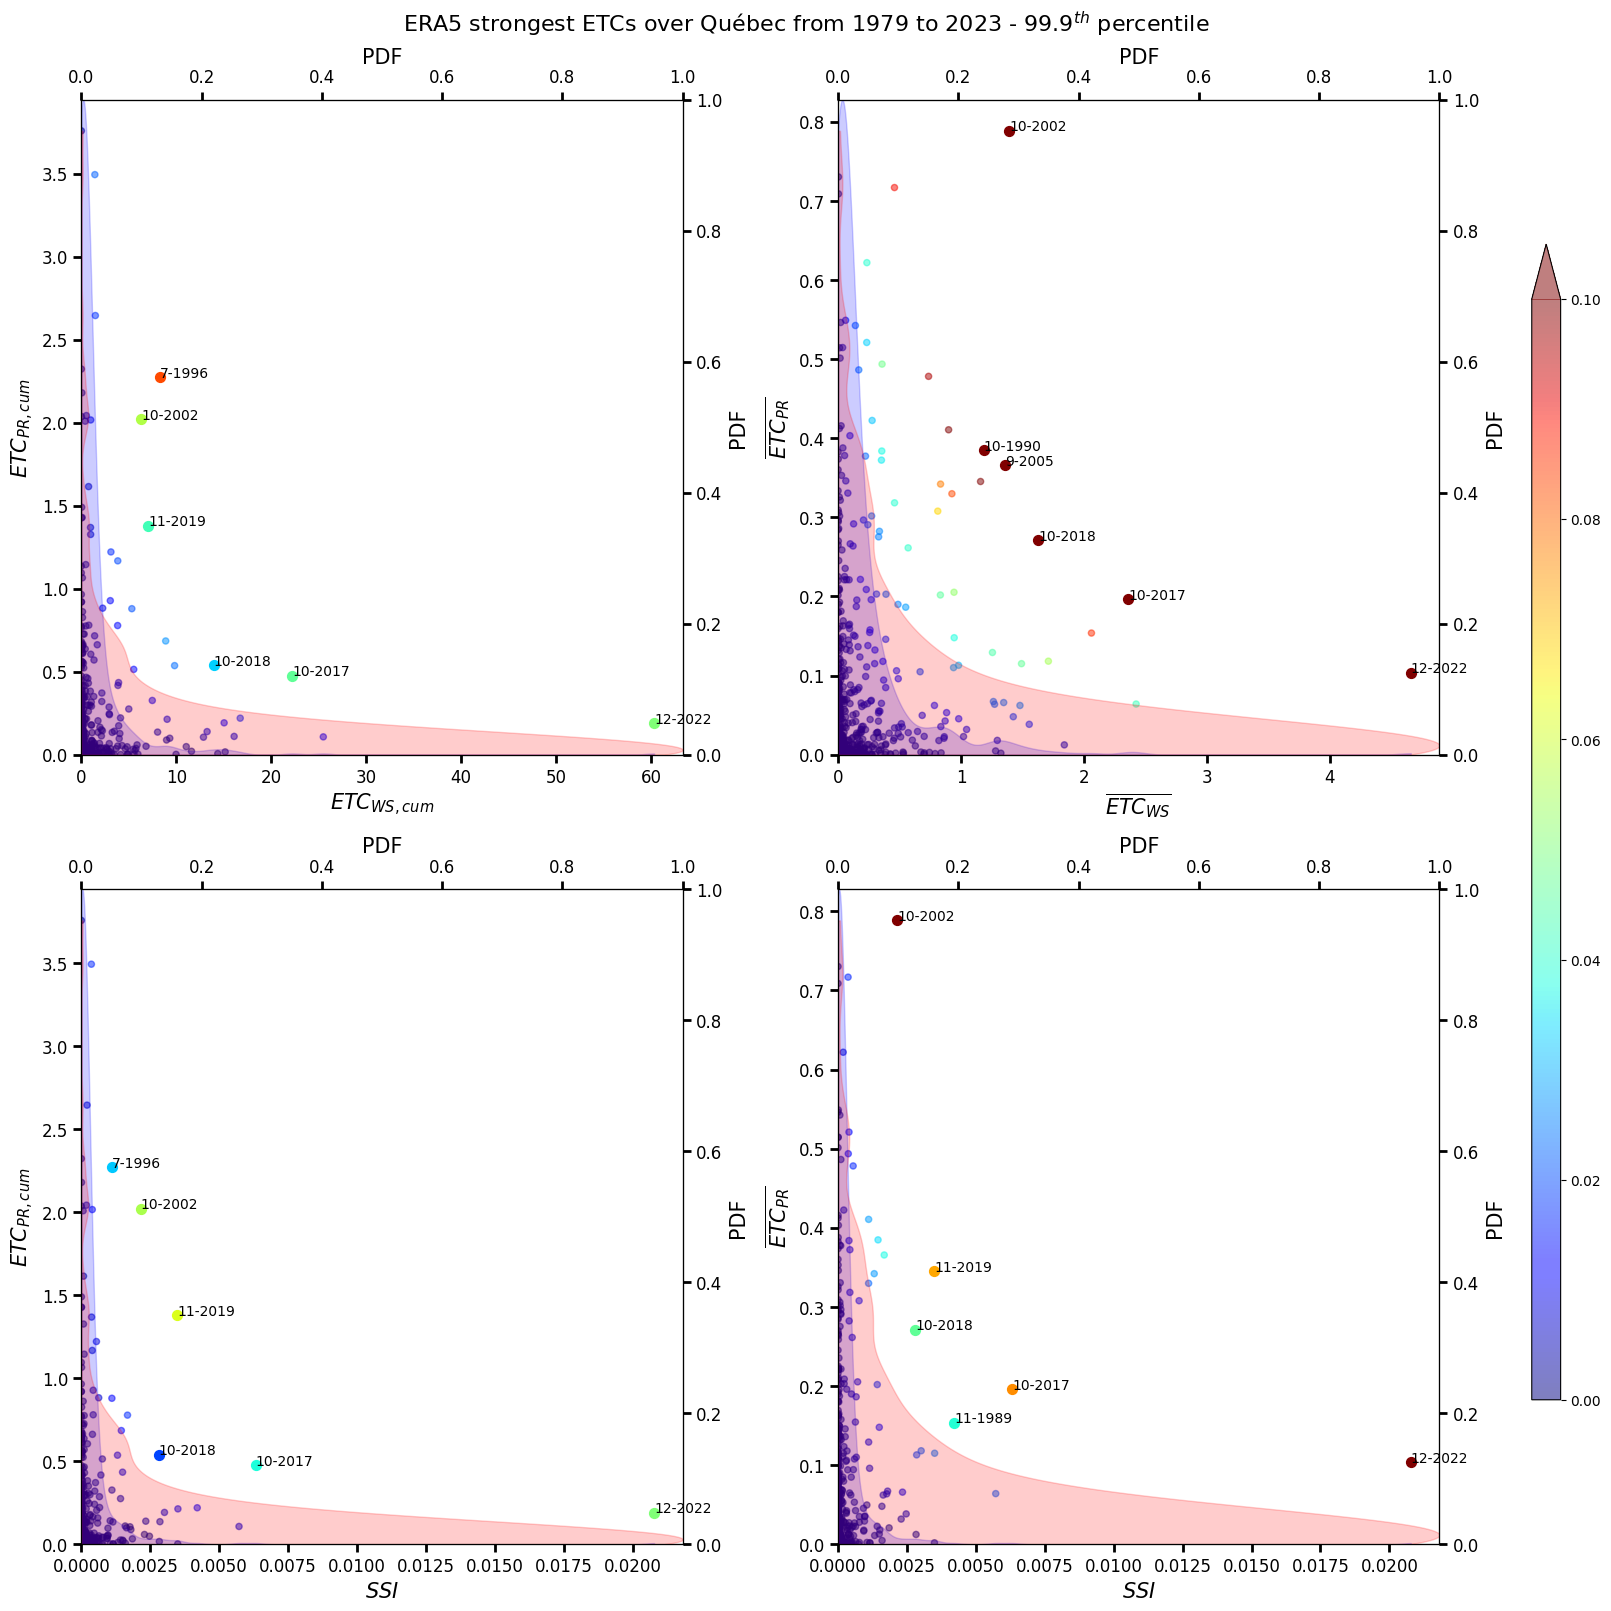

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16), constrained_layout=True)

for params in plot_params:
    
    # Récupération des valeurs x et y
    x = [EETC_dict[k][params["var_wind"]].sel(quantile=quantile).values for k in params["rank_var"]]
    y = [EETC_dict[k][params["var_precip"]].sel(quantile=quantile).values for k in params["rank_var"]]
    
    colors = [params["colors"][k] for k in params["rank_var"]]
    dates = params["dates"]
    ax = axes[params["ax_index"]]
    # vmax = max(combined_scores[sorted_EETC_cum_rank[0]], combined_avg_scores[sorted_EETC_cum_avg_rank[0]], combined_SSI_scores[sorted_EETC_cum_SSI_rank[0]], combined_SSI_avg_scores[sorted_EETC_cum_avg_SSI_rank[0]])
    vmax = 0.10
    
    # Scatter plot des points avec les couleurs définies
    sc = ax.scatter(x, y, c=colors, s=20, alpha=0.5, cmap='jet', vmin=0, vmax=vmax)

    for i in range(6):
        ax.scatter(x[i], y[i], c=colors[i], s=50, cmap='jet', vmin=sc.norm.vmin, vmax=sc.norm.vmax)
        ax.annotate(f"{EETC_dict[params['rank_var'][i]]['min_pressure_date'].month}-{EETC_dict[params['rank_var'][i]]['min_pressure_date'].year}", (x[i], y[i]), fontsize=10)
    
    ax_twinx = ax.twinx()
    kde_x = gaussian_kde(x)
    x_vals = np.linspace(min(x), max(x), 1000)
    density_x = kde_x(x_vals)
    density_x /= density_x.max()  # Normalisation de la densité
    ax_twinx.fill_between(x_vals, density_x, color='blue', alpha=0.2)
    ax_twinx.set_ylim(0, 1)
    ax_twinx.tick_params(axis='y', which='major', labelsize=12, width=2, length=6)
    ax_twinx.tick_params(axis='y', which='minor', labelsize=10, width=1.5, length=4)
    ax_twinx.set_ylabel('PDF', fontsize=15)  # Correction ici

    ax_twiny = ax.twiny()
    kde_y = gaussian_kde(y)
    y_vals = np.linspace(min(y), max(y), 1000)
    density_y = kde_y(y_vals)
    density_y /= density_y.max()  # Normalisation de la densité
    ax_twiny.fill_betweenx(y_vals, density_y, color='red', alpha=0.2)
    ax_twiny.set_xlim(0, 1)
    ax_twiny.tick_params(axis='x', which='major', labelsize=12, width=2, length=6)
    ax_twiny.tick_params(axis='x', which='minor', labelsize=10, width=1.5, length=4)
    ax_twiny.set_xlabel('PDF', fontsize=15)  # Correction ici
    
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(params["xlabel"], fontsize=15)
    ax.set_ylabel(params["ylabel"], fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)

# Colorbar pour les points du scatter
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', shrink=0.8, pad=0.02, aspect=40, extend='max')

fig.suptitle(f"{sim} strongest ETCs over Québec from 1979 to {endyear} - ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'ERA5 strongest ETCs over Québec from 1979 to 2023 - $99.9^{th}$ percentile')

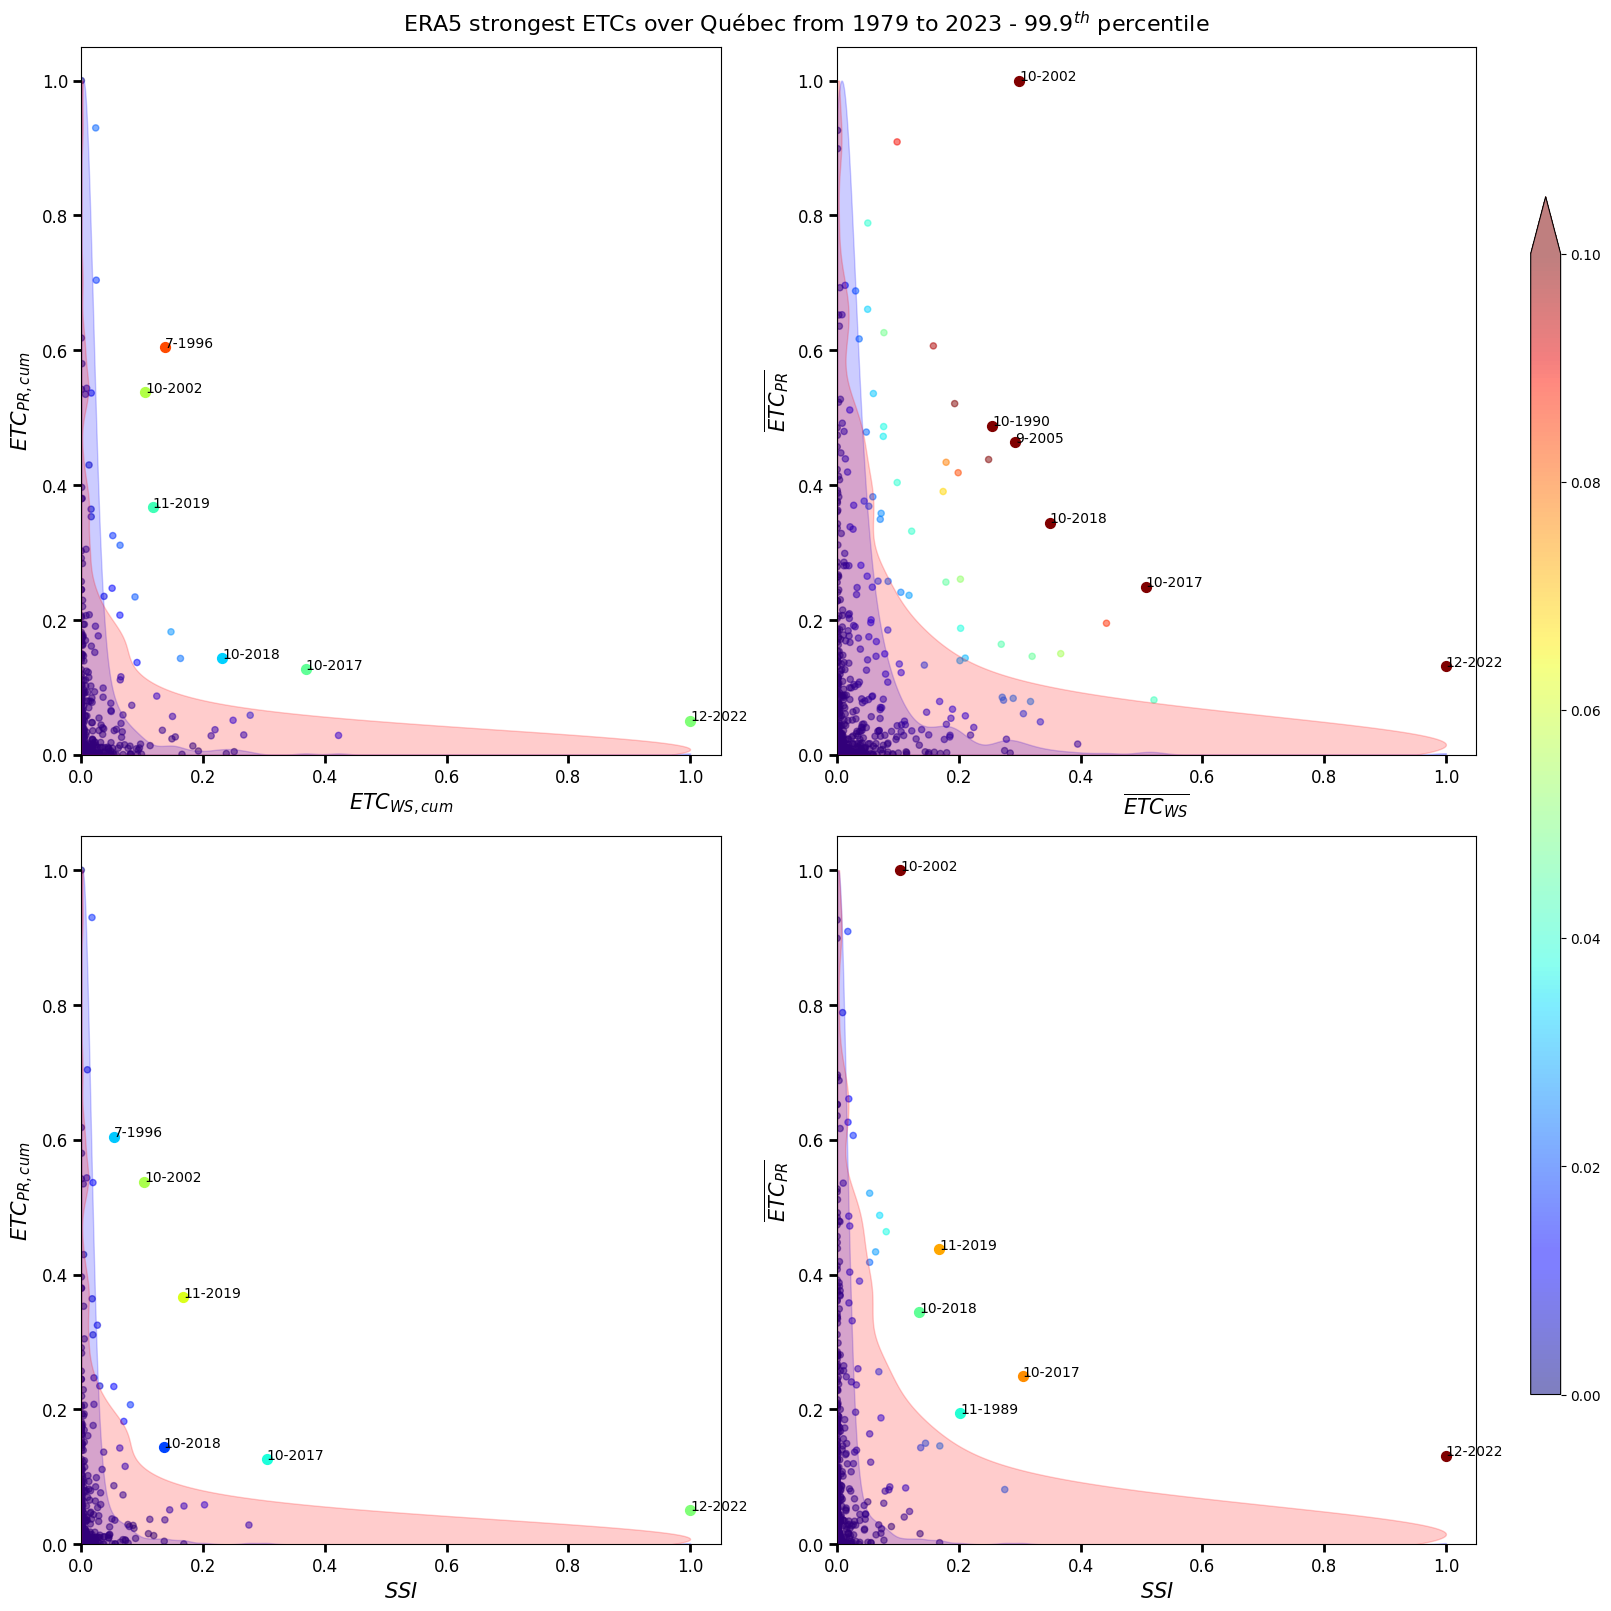

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16), constrained_layout=True)

for params in plot_params:
    
    # Récupération des valeurs x et y
    x = [EETC_dict_norm[k][params["var_wind"]].sel(quantile=quantile).values for k in params["rank_var"]]
    y = [EETC_dict_norm[k][params["var_precip"]].sel(quantile=quantile).values for k in params["rank_var"]]
    
    colors = [params["colors"][k] for k in params["rank_var"]]
    dates = params["dates"]
    ax = axes[params["ax_index"]]
    # vmax = max(combined_scores[sorted_EETC_cum_rank[0]], combined_avg_scores[sorted_EETC_cum_avg_rank[0]], combined_SSI_scores[sorted_EETC_cum_SSI_rank[0]], combined_SSI_avg_scores[sorted_EETC_cum_avg_SSI_rank[0]])
    vmax = 0.10
    
    # Scatter plot des points avec les couleurs définies
    sc = ax.scatter(x, y, c=colors, s=20, alpha=0.5, cmap='jet', vmin=0, vmax=vmax)

    for i in range(6):
        ax.scatter(x[i], y[i], c=colors[i], s=50, cmap='jet', vmin=sc.norm.vmin, vmax=sc.norm.vmax)
        ax.annotate(f"{EETC_dict[params['rank_var'][i]]['min_pressure_date'].month}-{EETC_dict[params['rank_var'][i]]['min_pressure_date'].year}", (x[i], y[i]), fontsize=10)
    
    kde_x = gaussian_kde(x)
    x_vals = np.linspace(min(x), max(x), 1000)
    density_x = kde_x(x_vals)
    density_x /= density_x.max()  # Normalisation de la densité
    ax.fill_between(x_vals, density_x, color='blue', alpha=0.2)

    kde_y = gaussian_kde(y)
    y_vals = np.linspace(min(y), max(y), 1000)
    density_y = kde_y(y_vals)
    density_y /= density_y.max()  # Normalisation de la densité
    ax.fill_betweenx(y_vals, density_y, color='red', alpha=0.2)

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(params["xlabel"], fontsize=15)
    ax.set_ylabel(params["ylabel"], fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)

# Colorbar pour les points du scatter
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', shrink=0.8, pad=0.02, aspect=40, extend='max')

fig.suptitle(f"{sim} strongest ETCs over Québec from 1979 to {endyear} - ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'ERA5 strongest ETCs over Québec from 1979 to 2023 - $99.9^{th}$ percentile')

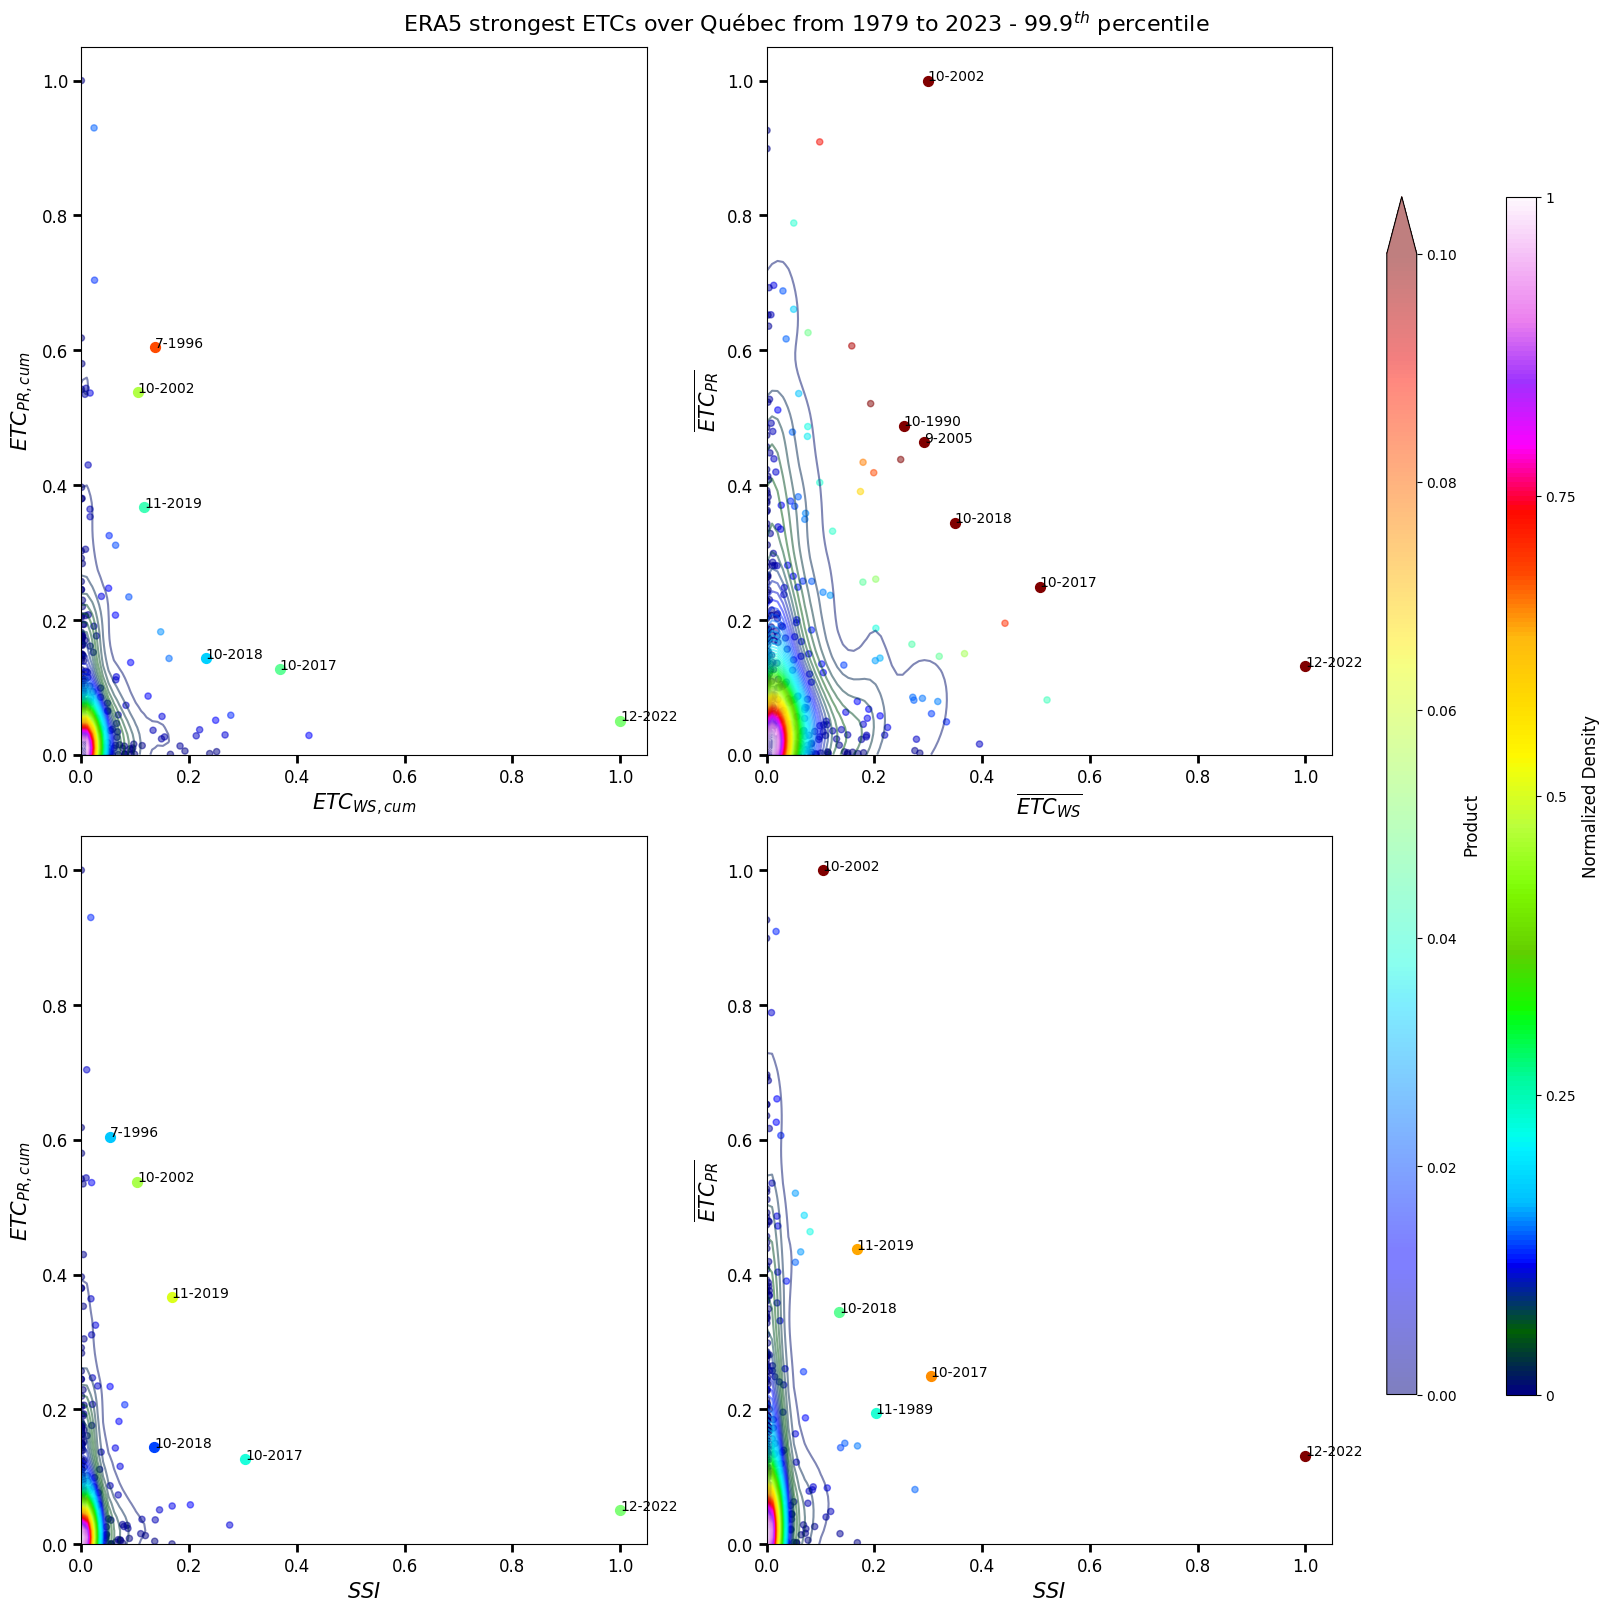

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16), constrained_layout=True)

for params in plot_params:
    
    # Récupération des valeurs x et y
    x = [EETC_dict_norm[k][params["var_wind"]].sel(quantile=quantile).values for k in params["rank_var"]]
    y = [EETC_dict_norm[k][params["var_precip"]].sel(quantile=quantile).values for k in params["rank_var"]]
    
    colors = [params["colors"][k] for k in params["rank_var"]]
    dates = params["dates"]
    ax = axes[params["ax_index"]]
    vmax = 0.10
    
    sc = ax.scatter(x, y, c=colors, s=20, alpha=0.5, cmap='jet', vmin=0, vmax=vmax)

    for i in range(6):
        ax.scatter(x[i], y[i], c=colors[i], s=50, cmap='jet', vmin=sc.norm.vmin, vmax=sc.norm.vmax)
        ax.annotate(f"{EETC_dict[params['rank_var'][i]]['min_pressure_date'].month}-{EETC_dict[params['rank_var'][i]]['min_pressure_date'].year}", (x[i], y[i]), fontsize=10)
        
    kde = gaussian_kde([x, y])
    x_grid, y_grid = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]
    grid_positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
    density = kde(grid_positions).reshape(x_grid.shape)
    density /= density.max()
    kde_2D = ax.contour(x_grid, y_grid, density, levels=100, cmap='gist_ncar', alpha=0.5)
    
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(params["xlabel"], fontsize=15)
    ax.set_ylabel(params["ylabel"], fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)

norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap='gist_ncar', norm=norm)
sm.set_array([])
cbar_kde_2D = fig.colorbar(sm, ax=axes, orientation='vertical', shrink=0.8, pad=0.02, aspect=40)
cbar_kde_2D.set_label('Normalized Density', fontsize=12)
cbar_kde_2D.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar_kde_2D.set_ticklabels(['0', '0.25', '0.5', '0.75', '1'])


cbar = fig.colorbar(sc, ax=axes, orientation='vertical', shrink=0.8, pad=0.02, aspect=40, extend='max')
cbar.set_label('Product', fontsize=12)

fig.suptitle(f"{sim} strongest ETCs over Québec from 1979 to {endyear} - ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'ERA5 strongest ETCs over Québec from 1979 to 2023 - $99.9^{th}$ percentile')

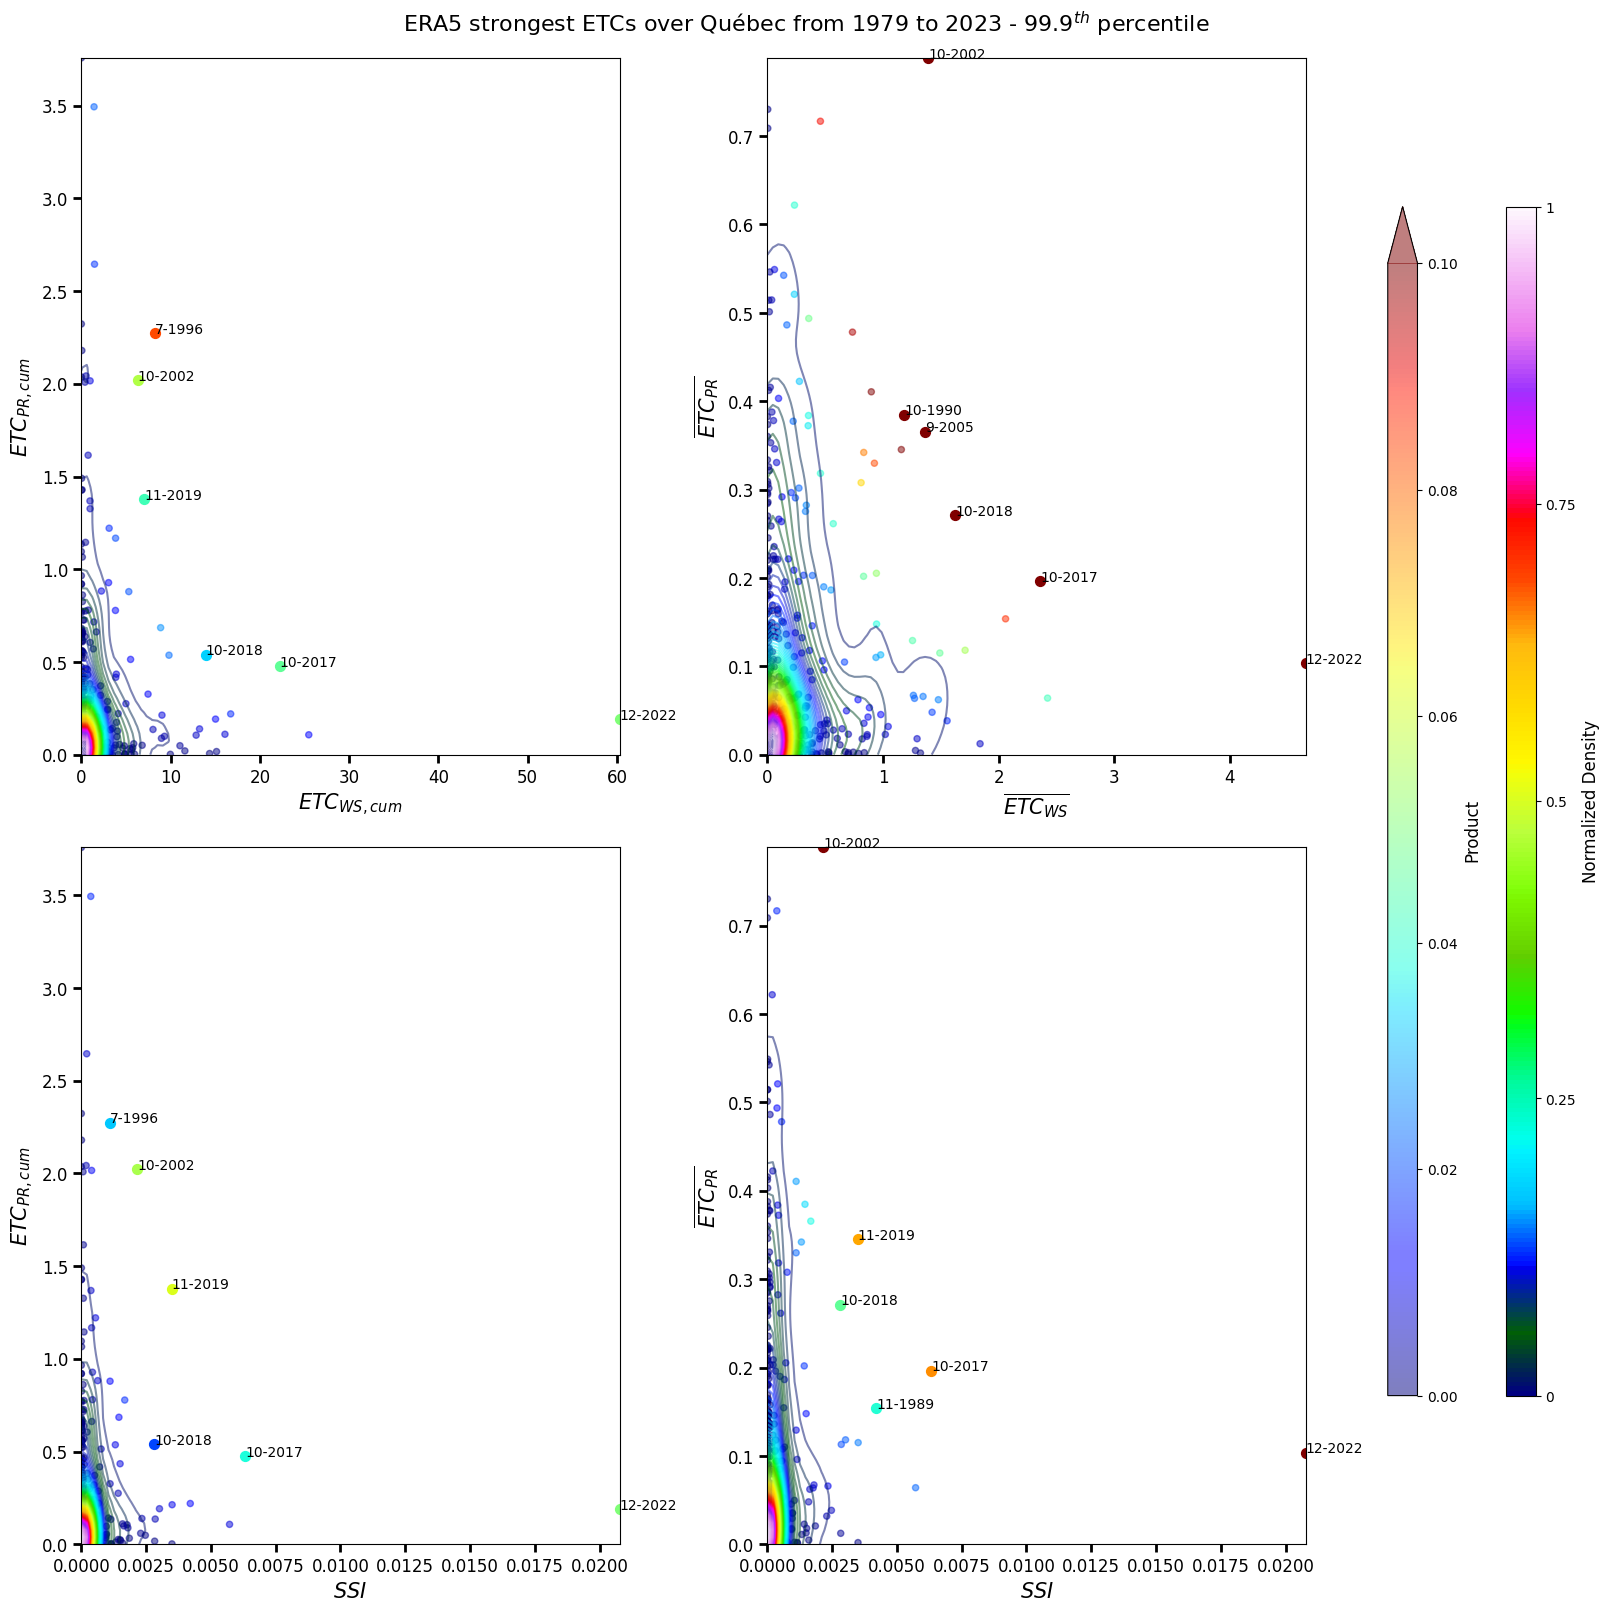

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16), constrained_layout=True)

for params in plot_params:
    
    # Récupération des valeurs x et y
    x = [EETC_dict[k][params["var_wind"]].sel(quantile=quantile).values for k in params["rank_var"]]
    y = [EETC_dict[k][params["var_precip"]].sel(quantile=quantile).values for k in params["rank_var"]]
    
    colors = [params["colors"][k] for k in params["rank_var"]]
    dates = params["dates"]
    ax = axes[params["ax_index"]]
    vmax = 0.10
    
    sc = ax.scatter(x, y, c=colors, s=20, alpha=0.5, cmap='jet', vmin=0, vmax=vmax)

    for i in range(6):
        ax.scatter(x[i], y[i], c=colors[i], s=50, cmap='jet', vmin=sc.norm.vmin, vmax=sc.norm.vmax)
        ax.annotate(f"{EETC_dict[params['rank_var'][i]]['min_pressure_date'].month}-{EETC_dict[params['rank_var'][i]]['min_pressure_date'].year}", (x[i], y[i]), fontsize=10)
        
    kde = gaussian_kde([x, y])
    x_grid, y_grid = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]
    grid_positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
    density = kde(grid_positions).reshape(x_grid.shape)
    density /= density.max()
    kde_2D = ax.contour(x_grid, y_grid, density, levels=100, cmap='gist_ncar', alpha=0.5)
    
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(params["xlabel"], fontsize=15)
    ax.set_ylabel(params["ylabel"], fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)

norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap='gist_ncar', norm=norm)
sm.set_array([])
cbar_kde_2D = fig.colorbar(sm, ax=axes, orientation='vertical', shrink=0.8, pad=0.02, aspect=40)
cbar_kde_2D.set_label('Normalized Density', fontsize=12)
cbar_kde_2D.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar_kde_2D.set_ticklabels(['0', '0.25', '0.5', '0.75', '1'])


cbar = fig.colorbar(sc, ax=axes, orientation='vertical', shrink=0.8, pad=0.02, aspect=40, extend='max')
cbar.set_label('Product of both metrics normalized', fontsize=12)

fig.suptitle(f"{sim} strongest ETCs over Québec from 1979 to {endyear} - ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)